In [1]:
import sys
import warnings
import os
import random
from pathlib import Path
from typing import List, Tuple

sys.path.append("../../")
warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from einops import rearrange
from PIL import Image
from skimage import measure
import rasterio as rio
from torchmetrics.classification import BinaryJaccardIndex, F1Score
from claymodel.finetune.segment.kelp_model import KelpSegmentor  # Your kelp model
from claymodel.finetune.segment.kelp_datamodule import KelpDataset  # Your dataset class
import cv2


In [3]:
print(torch.__version__)
print(torch.version.cuda)  # Should print the version of CUDA PyTorch is using
print("cuDNN version:", torch.backends.cudnn.version())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set the device to GPU if available, otherwise use CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

2.7.1+cu118
11.8
cuDNN version: 90100
cuda


### Define paths and parameters

In [4]:
# Model checkpoints
KELP_CHECKPOINT_PATH = r"C:\clay\clay-model\checkpoints\kelp_segment\kelp-binary-segment_epoch-98_val-iou-0.7317.ckpt"
CLAY_CHECKPOINT_PATH = r"C:\clay\clay-model\checkpoints\clay-v1.5.ckpt"

# Normalization parameters (user-provided)  This needs to be set based on the bands selceted in KelpDataset class, load_image method
# The bands order in the dataset: B2,B3,B4,B8,B5,B6,B7,B8A,B11,B12,Substrate,Bathymetry
# For the selected bands, the user needs to provide mean and std values. Use the notebook calculate_mean_std.ipynb
mean_per_channel = [200.85772705078125, 250.04220581054688, 140.90208435058594, 873.17236328125, 295.90692138671875, 701.5117797851562, 832.185546875, 908.3177490234375, 402.9516906738281, 210.0332794189453] # 701.5117797851562, 832.185546875, 908.3177490234375, 402.9516906738281, 210.0332794189453
std_per_channel = [161.0935821533203, 214.2581787109375, 206.62655639648438, 1227.9498291015625, 368.43585205078125, 953.573486328125, 1147.3150634765625, 1267.2421875, 594.2291259765625, 348.8812561035156] # 953.573486328125, 1147.3150634765625, 1267.2421875, 594.2291259765625, 348.8812561035156

### Model Loading

In [5]:
import torch
import gc
import os

def check_gpu_memory():
    """Check and print current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3  # GB
        reserved = torch.cuda.memory_reserved() / 1024**3    # GB
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3  # GB
        print(f"GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB, Total: {total:.2f}GB")
        return allocated, reserved, total
    return 0, 0, 0

def clear_gpu_memory():
    """Aggressive GPU memory cleanup"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.synchronize()
    gc.collect()

def load_kelp_model_gpu_optimized(kelp_checkpoint_path, clay_checkpoint_path):
    """
    GPU-optimized loading that prevents memory crashes
    """
    print("=== GPU-Optimized Model Loading ===")
    
    # Initial cleanup
    clear_gpu_memory()
    check_gpu_memory()
    
    # Step 1: Load checkpoint metadata only
    print("\n1. Loading checkpoint metadata...")
    checkpoint_keys = []
    hparams = {}
    
    # Load just the keys first to see what we're dealing with
    checkpoint = torch.load(kelp_checkpoint_path, map_location='cpu')
    checkpoint_keys = list(checkpoint.keys())
    if 'hyper_parameters' in checkpoint:
        hparams = checkpoint['hyper_parameters'].copy()
    
    print(f"Checkpoint keys: {checkpoint_keys}")
    print(f"Hyperparameters: {hparams}")
    
    # Clean hyperparameters
    clean_hparams = {
        'num_classes': 1,  # Binary segmentation - add this manually
        'ckpt_path': clay_checkpoint_path,
        'lr': hparams.get('lr', 1e-4),  # Match your default
        'wd': hparams.get('wd', 0.05),
        'b1': hparams.get('b1', 0.9),
        'b2': hparams.get('b2', 0.95),
        'threshold': hparams.get('threshold', 0.5),
    }
    
    # Step 2: Create model on CPU first
    print("\n2. Creating model on CPU...")
    clear_gpu_memory()
    
    # Set environment variables for better memory management
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
    
    model = KelpSegmentor(**clean_hparams)
    print("✓ Model created on CPU")
    
    # Step 3: Load weights on CPU
    print("\n3. Loading weights on CPU...")
    if 'state_dict' in checkpoint:
        missing_keys, unexpected_keys = model.load_state_dict(
            checkpoint['state_dict'], strict=False
        )
        print(f"✓ Weights loaded. Missing: {len(missing_keys)}, Unexpected: {len(unexpected_keys)}")
    
    # Clean up checkpoint from memory immediately
    del checkpoint
    clear_gpu_memory()
    
    model.eval()
    
    # Step 4: Move to GPU in stages
    print("\n4. Moving to GPU...")
    check_gpu_memory()
    
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    try:
        # Move model to GPU
        model = model.to(device)
        print(f"✓ Model moved to {device}")
        
        # Check final memory usage
        check_gpu_memory()
        
        return model
        
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"❌ GPU out of memory: {e}")
            print("Trying with CPU inference...")
            clear_gpu_memory()
            model = model.cpu()
            return model
        else:
            raise e

def load_model_minimal_memory(kelp_checkpoint_path, clay_checkpoint_path):
    """
    Minimal memory approach - load only what's necessary
    """
    print("=== Minimal Memory Loading ===")
    clear_gpu_memory()
    
    # Create model with minimal initialization
    print("Creating minimal model...")
    
    # Use a simple approach - create model and load weights
    model = KelpSegmentor(ckpt_path=clay_checkpoint_path,num_classes=1)
    
    # Load checkpoint and extract only state_dict
    print("Loading checkpoint state dict only...")
    checkpoint = torch.load(kelp_checkpoint_path, map_location='cpu')
    
    if 'state_dict' in checkpoint:
        # Load weights with error handling
        try:
            model.load_state_dict(checkpoint['state_dict'], strict=False)
            print("✓ State dict loaded successfully")
        except Exception as e:
            print(f"State dict loading error: {e}")
            # Try to load matching keys only
            model_state = model.state_dict()
            checkpoint_state = checkpoint['state_dict']
            
            filtered_dict = {k: v for k, v in checkpoint_state.items() 
                           if k in model_state and v.size() == model_state[k].size()}
            
            model.load_state_dict(filtered_dict, strict=False)
            print(f"✓ Loaded {len(filtered_dict)} matching parameters")
    
    # Immediate cleanup
    del checkpoint
    clear_gpu_memory()
    
    model.eval()
    
    # Move to GPU carefully
    device = torch.device('cuda')
    try:
        model = model.to(device)
        print(f"✓ Model on {device}")
        check_gpu_memory()
        return model
    except RuntimeError as e:
        print(f"GPU loading failed: {e}")
        return model.cpu()

# Main function to try different approaches
def get_model(kelp_checkpoint_path, clay_checkpoint_path):
    """
    Main loading function with multiple fallback strategies
    """
    strategies = [
        ("GPU Optimized", load_kelp_model_gpu_optimized),
        ("Minimal Memory", load_model_minimal_memory),
    ]
    
    for strategy_name, strategy_func in strategies:
        try:
            print(f"\n{'='*50}")
            print(f"Trying {strategy_name} Loading Strategy")
            print(f"{'='*50}")
            
            model = strategy_func(kelp_checkpoint_path, clay_checkpoint_path)
            
            print(f"\n✅ SUCCESS: {strategy_name} loading worked!")
            check_gpu_memory()
            return model
            
        except Exception as e:
            print(f"\n❌ {strategy_name} failed: {e}")
            clear_gpu_memory()
            continue
    
    raise RuntimeError("All loading strategies failed!")

# Usage:
"""
# Clear any existing GPU memory
clear_gpu_memory()
check_gpu_memory()

# Load model
print("Loading kelp segmentation model...")
model = get_model(KELP_CHECKPOINT_PATH, CLAY_CHECKPOINT_PATH)
print("Model loaded successfully!")

# Check final state
print(f"Model device: {next(model.parameters()).device}")
check_gpu_memory()
"""

'\n# Clear any existing GPU memory\nclear_gpu_memory()\ncheck_gpu_memory()\n\n# Load model\nprint("Loading kelp segmentation model...")\nmodel = get_model(KELP_CHECKPOINT_PATH, CLAY_CHECKPOINT_PATH)\nprint("Model loaded successfully!")\n\n# Check final state\nprint(f"Model device: {next(model.parameters()).device}")\ncheck_gpu_memory()\n'

In [6]:
# Step 3: Full loading (only if step 2 worked)
print("\nStep 3: Full model loading...")
try:
    clear_gpu_memory()
    model = get_model(KELP_CHECKPOINT_PATH, CLAY_CHECKPOINT_PATH)
    print("✅ Full model loading successful!")
    print(f"Final model device: {next(model.parameters()).device}")
    check_gpu_memory()
except Exception as e:
    print(f"❌ Full loading failed: {e}")


Step 3: Full model loading...

Trying GPU Optimized Loading Strategy
=== GPU-Optimized Model Loading ===
GPU Memory - Allocated: 0.00GB, Reserved: 0.00GB, Total: 15.99GB

1. Loading checkpoint metadata...
Checkpoint keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'hparams_name', 'hyper_parameters']
Hyperparameters: {'num_classes': 1, 'ckpt_path': 'checkpoints/clay-v1.5.ckpt', 'lr': 1e-05, 'wd': 0.05, 'b1': 0.9, 'b2': 0.95, 'threshold': 0.5, '_instantiator': 'lightning.pytorch.cli.instantiate_module'}

2. Creating model on CPU...
Loaded parameter: cls_token with size torch.Size([1, 1, 1024])
Loaded parameter: patch_embedding.weight_generator.weight_tokens with size torch.Size([128, 128])
Loaded parameter: patch_embedding.weight_generator.bias_token with size torch.Size([1, 128])
Loaded parameter: patch_embedding.weight_generator.encoder.layers.0.self_attn.in_proj_weight with size torch.Size([384, 128])
Loaded parameter: patch_embedding.weight_generato

### Run Inference on S-2 Images


Processing folder: S2A_MSIL2A_20230816T191911_N0510_R099_T10UCA_20241022T105420


Predicting on Tiles:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏ | 25924/26244 [10:29<00:07, 41.18it/s]


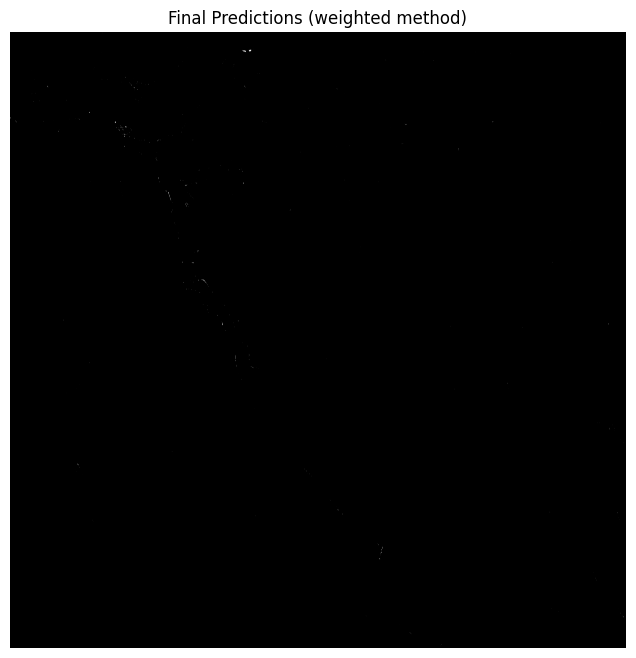

Completed processing: S2A_MSIL2A_20230816T191911_N0510_R099_T10UCA_20241022T105420 -> S2A_MSIL2A_20230816T191911_N0510_R099_T10UCA_20241022T105420_ClayModel_10bands.tif
Processing folder: S2B_MSIL2A_20250721T191909_N0511_R099_T10UCA_20250721T225550


Predicting on Tiles:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏ | 25924/26244 [09:43<00:07, 44.46it/s]


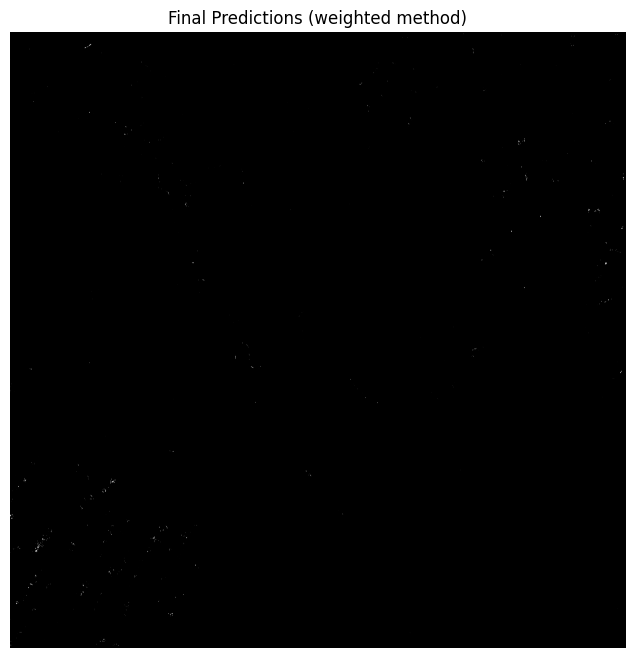

Completed processing: S2B_MSIL2A_20250721T191909_N0511_R099_T10UCA_20250721T225550 -> S2B_MSIL2A_20250721T191909_N0511_R099_T10UCA_20250721T225550_ClayModel_10bands.tif
All folders processed!


In [9]:
#  Sep 2025 - 
# 1.padding (zero-padding was failing in the edge tiles, so using mirror padding)
# 2.Added two different methods (halo method and weighted average method). In the halo method: For each tile (that's not in the edge), we
# only use predictions from the center region of size (tile_size - 2*halo_size). In the weighted average method, we give weight 1 to the 
# predictions from a square sized halo size by halo size in the centre of each tile and the rest of the tile get weight values faded from 
# 1 to 0 going from the edge of the square in the centre to the edge of the tile. Specifically, A. Accumulation Process:Each tile adds its 
# weighted prediction to the accumulator: predictions += tile_pred * tile_weights. Then, each tile adds its weights to the weight accumulator: 
# weight_accumulator += tile_weights B. Final Normalization: At the end, we divide by total weights: predictions = predictions / weight_accumulator
# This gives us the weighted average of all predictions that contributed to each pixel

import os
import glob
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from tqdm import tqdm


def normalize_tile_mean_std(tile, mean_per_channel, std_per_channel):
    """Applies mean and std normalization to each channel of the input tile (H, W, C) using vectorization."""
    tile = np.nan_to_num(tile).astype(np.float32)  # Handle NaNs and ensure float type
    mean = np.array(mean_per_channel, dtype=np.float32)
    std = np.array(std_per_channel, dtype=np.float32)
    # Reshape mean and std to match tile's shape for broadcasting
    mean = mean[np.newaxis, np.newaxis, :]
    std = std[np.newaxis, np.newaxis, :]
    normalized_tile = (tile - mean) / (std + 1e-8)
    return normalized_tile


def create_weight_map(tile_size, halo_size):
    """Create a weight map that gives less weight to edge pixels and more to center."""
    weight_map = np.ones((tile_size, tile_size), dtype=np.float32)
    
    # Create a linear fade from edge to center
    for i in range(halo_size):
        fade_weight = (i + 1) / halo_size
        # Top and bottom edges
        weight_map[i, :] = fade_weight
        weight_map[tile_size-1-i, :] = fade_weight
        # Left and right edges
        weight_map[:, i] = np.minimum(weight_map[:, i], fade_weight)
        weight_map[:, tile_size-1-i] = np.minimum(weight_map[:, tile_size-1-i], fade_weight)
    
    return weight_map


class DatasetInference:
    def __init__(self, main_directory, model, tile_size=512, overlap=0.7, mean_per_channel=None, std_per_channel=None, halo_size=64, padding_mode='reflect'):
        self.main_directory = main_directory
        self.tile_size = tile_size
        self.overlap = max(overlap, 0.7)  # Ensure minimum overlap of 0.7 for better stitching
        self.model = model.to(DEVICE)  # The trained model
        self.mean_per_channel = mean_per_channel
        self.std_per_channel = std_per_channel
        self.halo_size = halo_size
        self.padding_mode = padding_mode  # 'reflect', 'edge', 'constant', or 'symmetric'
        
        # Create weight map for weighted averaging
        self.weight_map = create_weight_map(tile_size, halo_size)

        # Get the four required file paths
        self.image_path1, self.image_path2= self.get_file_paths(main_directory)

        # Load the image and process it
        self.image, self.metadata = self.load_image()


    def get_file_paths(self, main_directory):
        """Retrieve the four file paths from the directory."""
        file_patterns = ["*_B2B3B4B8.tif", "*_B5B6B7B8A_B11B12.tif"]
        file_paths = []

        for pattern in file_patterns:
            matching_files = glob.glob(os.path.join(main_directory, pattern))
            if len(matching_files) != 1:
                raise ValueError(f"Expected one file for pattern {pattern}, found {len(matching_files)}.")
            file_paths.append(matching_files[0])

        return file_paths  # Returns four paths in order

    def load_image(self):
        """Load all image bands from the four source files (10m bands)."""

        # Load 10m bands (B2, B3, B4, B8)
        with rasterio.open(self.image_path1) as src1:
            image1 = src1.read([1, 2, 3, 4])  # Read bands at 10m resolution
            image1 = np.transpose(image1, (1, 2, 0)).astype(np.float32)  # Shape (H, W, 4)
            metadata = src1.meta  # Save metadata for later use

        # Load 20m bands (B5, B6, B7, B8A, B11, B12)
        with rasterio.open(self.image_path2) as src2:
            #rasterio.open().read() function accepts the indexes parameter to specify which bands to read from a
            # multi-band raster. This parameter allows you to select specific bands by providing their indices. In Rasterio, band indices start at 1
            # If you want bands 5, 6, 7, and 8a, for example, you should write src2.read(indexes=[1], out_shape=(1, image1.shape[0], image1.shape[1],
            # resampling=Resampling.nearest)
            image2 = src2.read(indexes=[1,2,3,4,5,6], out_shape=(
                6,  # change this and indexes based on the bands included in the training. Only band B5 (red edge), which is band index 1, was used.
                image1.shape[0],  # Match height of 10m bands
                image1.shape[1]    # Match width of 10m bands
            ), resampling=Resampling.nearest)  # Upsample using nearest neighbor
            image2 = np.transpose(image2, (1, 2, 0)).astype(np.float32)  # Shape (H, W, 1)

        # Merge all bands together
        self.image = np.concatenate((image1, image2), axis=-1)  # Shape (H, W, C)
        self.image = self.image[..., [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]  # selection based on what the model is trained on (attention: zero-based)
                                                                                        #0-3: RGBNIR 4:B5

        return self.image, metadata

    def generate_tiles(self, image):
        """Generator that yields one tile and its coordinates at a time."""
        h, w, c = image.shape
        tile_size = self.tile_size
        overlap = self.overlap
        step_size = int(tile_size * (1 - overlap))
    
        # Main tiling loop
        for i in range(0, h - tile_size + 1, step_size):
            for j in range(0, w - tile_size + 1, step_size):
                tile = image[i:i+tile_size, j:j+tile_size]
                if self.mean_per_channel is not None and self.std_per_channel is not None:
                    tile = normalize_tile_mean_std(tile, self.mean_per_channel, self.std_per_channel)
                yield tile, (i, j)
    
        # Edge padding - handle incomplete tiles at edges
        edge_positions = []
        
        # Right edge tiles
        if w % step_size != 0 or w - tile_size < 0:
            for i in range(0, h - tile_size + 1, step_size):
                j_start = max(0, w - tile_size)
                if j_start not in [j for _, j in edge_positions if i == i]:  # Avoid duplicates
                    edge_positions.append((i, j_start))
        
        # Bottom edge tiles
        if h % step_size != 0 or h - tile_size < 0:
            for j in range(0, w - tile_size + 1, step_size):
                i_start = max(0, h - tile_size)
                if i_start not in [i for i, _ in edge_positions if j == j]:  # Avoid duplicates
                    edge_positions.append((i_start, j))
        
        # Bottom-right corner tile
        if (h % step_size != 0 or h - tile_size < 0) and (w % step_size != 0 or w - tile_size < 0):
            i_start = max(0, h - tile_size)
            j_start = max(0, w - tile_size)
            if (i_start, j_start) not in edge_positions:
                edge_positions.append((i_start, j_start))
        
        # Generate edge tiles
        for i, j in edge_positions:
            tile = image[i:min(i+tile_size, h), j:min(j+tile_size, w)]
            tile = self.pad_tile(tile)
            if self.mean_per_channel is not None and self.std_per_channel is not None:
                tile = normalize_tile_mean_std(tile, self.mean_per_channel, self.std_per_channel)
            yield tile, (i, j)

    def pad_tile(self, tile):
        """Apply intelligent padding to the tile if it's smaller than the tile_size."""
        pad_h = max(0, self.tile_size - tile.shape[0])
        pad_w = max(0, self.tile_size - tile.shape[1])
        
        if pad_h == 0 and pad_w == 0:
            return tile
            
        # Use the specified padding mode
        if self.padding_mode == 'reflect':
            # Handle cases where tile is too small for reflect padding
            if tile.shape[0] == 1 and pad_h > 0:
                mode = 'edge'  # Fall back to edge for very small tiles
            elif tile.shape[1] == 1 and pad_w > 0:
                mode = 'edge'
            else:
                mode = 'reflect'
        else:
            mode = self.padding_mode
            
        return np.pad(tile, ((0, pad_h), (0, pad_w), (0, 0)), mode=mode)

    def count_tiles(self, image_shape, tile_size, overlap):
        """Count how many tiles will be generated, exactly matching generate_tiles()."""
        h, w, _ = image_shape
        step_size = int(tile_size * (1 - overlap))
        count = 0
    
        # Main tiling loop
        for i in range(0, h - tile_size + 1, step_size):
            for j in range(0, w - tile_size + 1, step_size):
                count += 1
    
        # Edge tiles count
        edge_positions = []
        
        # Right edge tiles
        if w % step_size != 0 or w - tile_size < 0:
            for i in range(0, h - tile_size + 1, step_size):
                j_start = max(0, w - tile_size)
                edge_positions.append((i, j_start))
        
        # Bottom edge tiles
        if h % step_size != 0 or h - tile_size < 0:
            for j in range(0, w - tile_size + 1, step_size):
                i_start = max(0, h - tile_size)
                edge_positions.append((i_start, j))
        
        # Bottom-right corner tile
        if (h % step_size != 0 or h - tile_size < 0) and (w % step_size != 0 or w - tile_size < 0):
            i_start = max(0, h - tile_size)
            j_start = max(0, w - tile_size)
            edge_positions.append((i_start, j_start))
        
        # Remove duplicates
        edge_positions = list(set(edge_positions))
        count += len(edge_positions)
    
        return count

    def _process_batch_weighted_averaging(self, tiles, coords, predictions, weight_accumulator):
        """Process batch using weighted averaging with halo method."""
        batch_tensor = torch.cat(tiles, dim=0).to(DEVICE)

        # Create the input dictionary that KelpSegmentor expects
        batch_input = {
            "pixels": batch_tensor,  # Shape: [batch_size, channels, height, width]
            "time": torch.zeros(batch_tensor.shape[0], 4).to(DEVICE),  # Dummy time values
            "latlon": torch.zeros(batch_tensor.shape[0], 4).to(DEVICE),  # Dummy lat/lon values
        }
        outputs = self.model(batch_input)
    
        # Handle binary output (thresholding)
        if outputs.shape[1] == 1:
            outputs = outputs.squeeze(1).sigmoid().cpu().numpy()  # Keep as probabilities for averaging
        else:
            outputs = torch.softmax(outputs, dim=1).cpu().numpy()  # Multi-class probabilities
    
        # Process each prediction in the batch
        for pred, (i, j) in zip(outputs, coords):
            # Calculate the region bounds in the full image
            end_i = min(i + self.tile_size, predictions.shape[0])
            end_j = min(j + self.tile_size, predictions.shape[1])
            
            # Calculate effective tile size (in case of edge tiles)
            effective_h = end_i - i
            effective_w = end_j - j
            
            # Get the corresponding portion of the prediction and weight map
            tile_pred = pred[:effective_h, :effective_w]
            tile_weights = self.weight_map[:effective_h, :effective_w]
            
            # Weighted accumulation
            predictions[i:end_i, j:end_j] += tile_pred * tile_weights
            weight_accumulator[i:end_i, j:end_j] += tile_weights


    def _process_batch_halo_method(self, tiles, coords, predictions):
        """Process batch using halo method with maximum value for overlapping regions."""
        batch_tensor = torch.cat(tiles, dim=0).to(DEVICE)
        # Create the input dictionary that KelpSegmentor expects
        batch_input = {
            "pixels": batch_tensor,  # Shape: [batch_size, channels, height, width]
            "time": torch.zeros(batch_tensor.shape[0], 4).to(DEVICE),  # Dummy time values
            "latlon": torch.zeros(batch_tensor.shape[0], 4).to(DEVICE),  # Dummy lat/lon values
        }
        outputs = self.model(batch_input)
    
        if outputs.shape[1] == 1:
            outputs = (outputs.squeeze(1) > 0.5).cpu().numpy().astype(np.uint8)
        else:
            outputs = outputs.argmax(dim=1).cpu().numpy().astype(np.uint8)
    
        for pred, (i, j) in zip(outputs, coords):
            # Calculate available space in full image
            max_h = predictions.shape[0] - i
            max_w = predictions.shape[1] - j
            
            # Determine halo boundaries based on tile position
            # Use full tile for edges, center region for interior tiles
            start_h = self.halo_size if (i > 0 and max_h > self.tile_size) else 0
            start_w = self.halo_size if (j > 0 and max_w > self.tile_size) else 0
            end_h = self.tile_size - self.halo_size if (i + self.tile_size < predictions.shape[0]) else min(self.tile_size, max_h)
            end_w = self.tile_size - self.halo_size if (j + self.tile_size < predictions.shape[1]) else min(self.tile_size, max_w)
            
            # Extract the appropriate region from prediction
            region_pred = pred[start_h:end_h, start_w:end_w]
            
            # Calculate corresponding position in full image
            full_start_h = i + start_h
            full_start_w = j + start_w
            full_end_h = full_start_h + region_pred.shape[0]
            full_end_w = full_start_w + region_pred.shape[1]
            
            # Get the existing predictions in this region
            existing_pred = predictions[full_start_h:full_end_h, full_start_w:full_end_w]
            
            # Take maximum value for overlapping areas (element-wise maximum)
            combined_pred = np.maximum(existing_pred, region_pred)
            
            # Update the predictions
            predictions[full_start_h:full_end_h, full_start_w:full_end_w] = combined_pred

    def run_model_on_tiles(self, batch_size=8, method='weighted'):
        """
        Run the model on tiles with improved edge handling.
        
        Args:
            batch_size (int): Number of tiles to process in each batch
            method (str): 'weighted' for weighted averaging or 'halo' for halo method
        """
        self.model.eval()
        
        if method == 'weighted':
            predictions = np.zeros_like(self.image[:, :, 0], dtype=np.float32)
            weight_accumulator = np.zeros_like(self.image[:, :, 0], dtype=np.float32)
        else:  # halo method
            predictions = np.zeros_like(self.image[:, :, 0], dtype=np.uint8)
    
        tile_generator = self.generate_tiles(self.image)
        total_tiles = self.count_tiles(self.image.shape, self.tile_size, self.overlap)
    
        batch_tiles = []
        batch_coords = []
    
        with torch.no_grad():
            for tile, (i, j) in tqdm(tile_generator, total=total_tiles, desc="Predicting on Tiles"):
                # Preprocess and add tile to batch
                tile_tensor = torch.tensor(tile).permute(2, 0, 1).unsqueeze(0).float()
                batch_tiles.append(tile_tensor)
                batch_coords.append((i, j))
    
                # Run batch when full
                if len(batch_tiles) == batch_size:
                    if method == 'weighted':
                        self._process_batch_weighted_averaging(batch_tiles, batch_coords, predictions, weight_accumulator)
                    else:
                        self._process_batch_halo_method(batch_tiles, batch_coords, predictions)
                    batch_tiles.clear()
                    batch_coords.clear()
    
            # Handle remaining tiles
            if batch_tiles:
                if method == 'weighted':
                    self._process_batch_weighted_averaging(batch_tiles, batch_coords, predictions, weight_accumulator)
                else:
                    self._process_batch_halo_method(batch_tiles, batch_coords, predictions)
    
        # Finalize predictions
        if method == 'weighted':
            # Avoid division by zero
            weight_accumulator = np.where(weight_accumulator == 0, 1, weight_accumulator)
            predictions = predictions / weight_accumulator
            
            # Convert back to binary/class predictions
            if predictions.ndim == 2:  # Binary case
                predictions = (predictions > 0.5).astype(np.uint8)
            else:  # Multi-class case
                predictions = np.argmax(predictions, axis=-1).astype(np.uint8)
    
        # Optional: visualize the final result
        plt.figure(figsize=(10, 8))
        plt.imshow(predictions, cmap='gray')
        plt.title(f"Final Predictions ({method} method)")
        plt.axis('off')
        plt.show()
    
        return predictions

    def __getitem__(self, idx):
        """Return the tile and its corresponding coordinates."""
        return self.tiles[idx], self.tile_coords[idx]

    def __len__(self):
        """Return the number of tiles."""
        return len(self.tiles)

    def save_output(self, predictions, output_path):
        """Save the reconstructed output as a GeoTIFF."""
        # Update predictions to uint8 if needed before saving
        predictions = predictions.astype(np.uint8)

        # Update the metadata, ensuring it matches the predictions
        updated_metadata = self.metadata.copy()
        updated_metadata.update({
            'driver': 'GTiff',
            'dtype': 'uint8',      # Make sure this matches predictions' dtype
            'count': 1,          # Single-band output
            'compress': 'lzw'      # Optional compression to reduce file size
        })

        # Save the file with rasterio, ensuring that spatial metadata is preserved
        with rasterio.open(output_path, 'w', **updated_metadata) as dst:
            dst.write(predictions, 1)  # Write data to the first band


# Updated usage code with multiple directories

# Set the directory containing multiple folders
directoryContainingFolders = r"C:\Users\mohsenghanbari\Downloads\q"
output_suffix = "_ClayModel_10bands.tif"

# Get all subdirectories
subfolders = [f.path for f in os.scandir(directoryContainingFolders) if f.is_dir()]

# Process each folder sequentially
for main_directory in subfolders:
    try:
        folder_name = os.path.basename(main_directory)
        output_filename = folder_name + output_suffix
        
        print(f"Processing folder: {folder_name}")
        
        # Initialize with improved parameters
        dataset = DatasetInference(
            main_directory=main_directory, 
            model=model, 
            mean_per_channel=mean_per_channel, 
            std_per_channel=std_per_channel,
            tile_size=224,
            overlap=0.7,  # Increased overlap
            halo_size=32,
            padding_mode='reflect'  # Use reflect padding instead of zero padding
        )
        
        # Run model with weighted averaging method (method='weighted') or you can also try halo method (method='halo')
        predictions = dataset.run_model_on_tiles(batch_size=8, method='weighted')
        
        output_path = os.path.join(main_directory, output_filename)
        dataset.save_output(predictions, output_path)
        
        print(f"Completed processing: {folder_name} -> {output_filename}")
        
    except Exception as e:
        print(f"Error processing folder {folder_name}: {str(e)}")
        print("Continuing with next folder...")
        continue

print("All folders processed!")